In [6]:
image_path = r"C:\Users\alias\Downloads\Peak.png"

image = cv2.imread(image_path)

if image is None:
    print("Ошибка: изображение не найдено!")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print("Изображение успешно загружено!")

Изображение успешно загружено!


Task 1  K-means


K = 2
Cluster centers:
[[203 135 118]
 [ 44  75  73]]


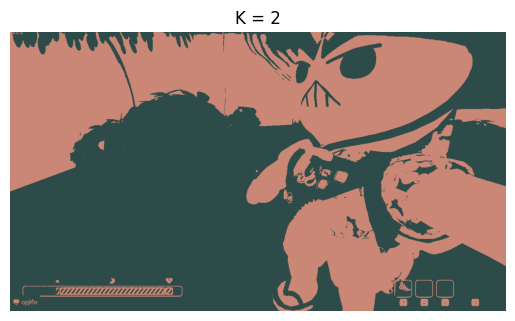


K = 4
Cluster centers:
[[212  89  63]
 [ 29  79  80]
 [200 176 168]
 [106  66  50]]


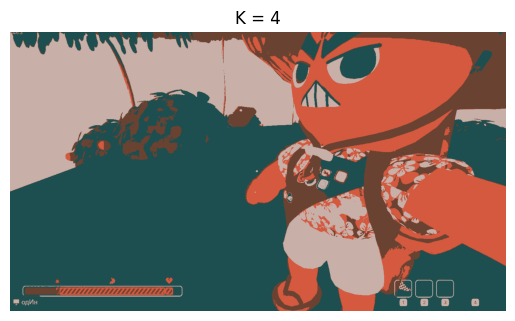


K = 6
Cluster centers:
[[206  83  59]
 [ 29  80  80]
 [207 185 176]
 [ 98  63  47]
 [241 140  87]
 [169 144 145]]


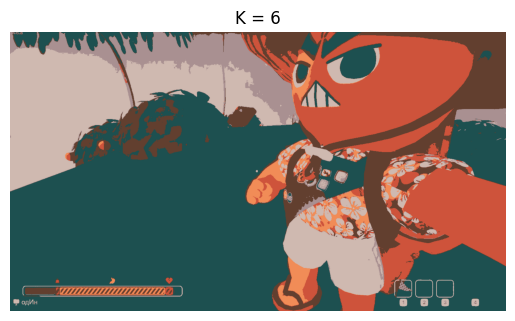

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

image = image_path = cv2.imread("C:\\Users\\alias\\Downloads\\Peak.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

pixel_values = image.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

for K in [2, 4, 6]:
    kmeans = KMeans(n_clusters=K, random_state=42)
    labels = kmeans.fit_predict(pixel_values)
    centers = np.uint8(kmeans.cluster_centers_)

    segmented_data = centers[labels]
    segmented_image = segmented_data.reshape(image.shape)

    print(f"\nK = {K}")
    print("Cluster centers:")
    print(centers)

    plt.imshow(segmented_image)
    plt.title(f"K = {K}")
    plt.axis("off")
    plt.show()

Task 2  Segmentation in HSV

Hue range: 0 - 20
Segmented pixels: 468227


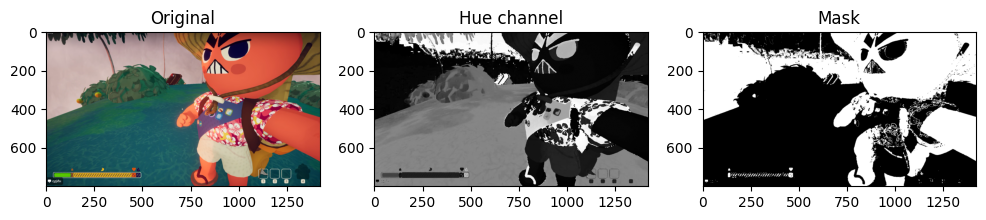

In [7]:
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
hue = hsv[:, :, 0]

lower_hue = 0
upper_hue = 20

mask = cv2.inRange(hue, lower_hue, upper_hue)

print("Hue range:", lower_hue, "-", upper_hue)
print("Segmented pixels:", np.sum(mask > 0))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(hue, cmap='gray')
plt.title("Hue channel")

plt.subplot(1,3,3)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

Task 3  Watershed

Number of segmented regions: 2


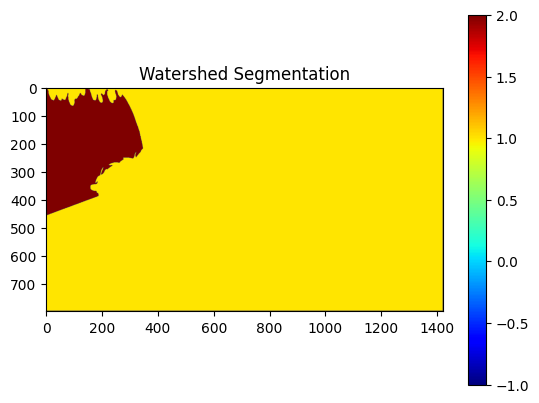

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)

ret, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(thresh, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

markers = cv2.watershed(image, markers)

num_regions = len(np.unique(markers)) - 1
print("Number of segmented regions:", num_regions)

plt.imshow(markers, cmap='jet')
plt.title("Watershed Segmentation")
plt.colorbar()
plt.show()

Task 4 Superpixels (SLIC)

Number of superpixels: 148


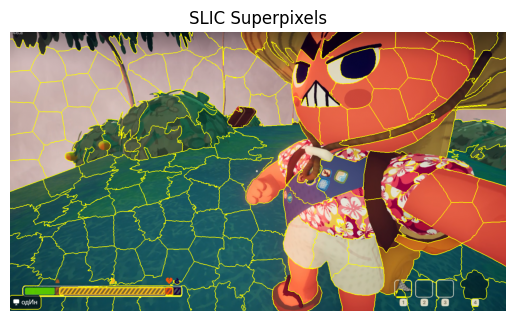

In [13]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries

segments = slic(image, n_segments=200, compactness=10)

print("Number of superpixels:", len(np.unique(segments)))

plt.imshow(mark_boundaries(image, segments))
plt.title("SLIC Superpixels")
plt.axis("off")
plt.show()

Task 5 - Comparison of methods

In [24]:
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)
    return np.sum(intersection) / np.sum(union)

iou = compute_iou(mask1 > 0, mask2 > 0)
print("IoU:", iou)

NameError: name 'mask1' is not defined

In [57]:
K = 2
kmeans = KMeans(n_clusters=K, random_state=42)
labels = kmeans.fit_predict(pixel_values)

segmented = labels.reshape(image.shape[:2])

In [58]:
mask_kmeans = (segmented == 1).astype(np.uint8)

In [59]:
mask_hsv = cv2.inRange(hue, 0, 20)
mask_hsv = (mask_hsv > 0).astype(np.uint8)

In [60]:
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)
    return np.sum(intersection) / np.sum(union)

In [61]:
iou = compute_iou(mask_kmeans, mask_hsv)
print("IoU:", iou)

IoU: 0.0771664660861631


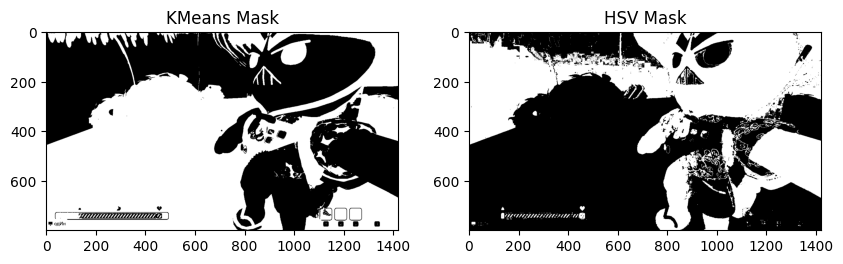

In [62]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_kmeans, cmap='gray')
plt.title("KMeans Mask")

plt.subplot(1,2,2)
plt.imshow(mask_hsv, cmap='gray')
plt.title("HSV Mask")

plt.show()

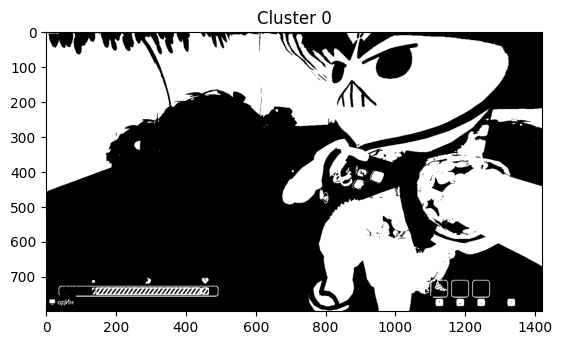

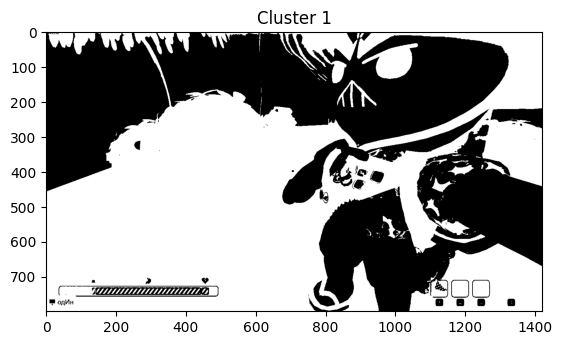

In [63]:
for i in range(K):
    mask = (segmented == i).astype(np.uint8)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Cluster {i}")
    plt.show()

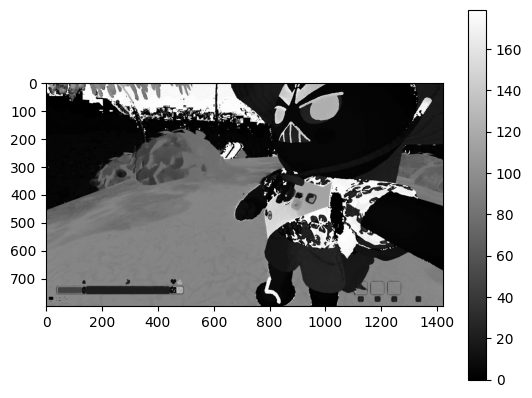

In [64]:
plt.imshow(hue, cmap='gray')
plt.colorbar()
plt.show()